# TBGuard Notebook 1 — CXR Model Training from Kaggle Montgomery + Shenzhen

This notebook fixes the earlier `Untitled123.ipynb` problems and trains **Model 1** for the final TB-Guard workflow.

It supports the Kaggle datasets you used:

- `aromak/montgomery-dataset`
- `aromak/shenzhen-dataset`

It fixes:

- hardcoded Kaggle token exposure
- images found only in Montgomery but not Shenzhen
- wrong root directory for metadata CSV search
- `AW_DIR` / `RAW_DIR` variable mistake
- blank/empty CSV discovery
- missing training/saving/export chunks after image discovery

Final output for Notebook 4:

```text
cxr_efficientnet_b0_tb.pt
cxr_model_metadata.json
cxr_training_history.csv
cxr_threshold_search.csv
demo_cxr_images.zip
cxr_model_artifacts.zip
```


## 0. Install packages

In [1]:
!pip install -q --upgrade kaggle
!pip install -q torch torchvision pandas pillow scikit-learn tqdm matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 4.5 MB/s eta 0:00:00


## 1. Imports and project folders

In [2]:
import os
import re
import json
import zipfile
import shutil
import random
from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

BASE_DIR = Path("tbguard_project")
DATA_DIR = BASE_DIR / "data"
CXR_DIR = DATA_DIR / "cxr"
RAW_DIR = CXR_DIR / "raw"
ARTIFACT_DIR = BASE_DIR / "artifacts"
MODEL_DIR = ARTIFACT_DIR / "models"
EXPORT_DIR = BASE_DIR / "exports"
DEMO_IMG_DIR = BASE_DIR / "demo_images"

for d in [DATA_DIR, CXR_DIR, RAW_DIR, ARTIFACT_DIR, MODEL_DIR, EXPORT_DIR, DEMO_IMG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR.resolve())
print("MODEL_DIR:", MODEL_DIR.resolve())

Device: cuda
RAW_DIR: /content/tbguard_project/data/cxr/raw
MODEL_DIR: /content/tbguard_project/artifacts/models


## 2. Configure Kaggle using the new `KGAT_...` token

Do **not** hardcode your token in the notebook. Paste it only when prompted.

If your token was ever visible in a screenshot or notebook, regenerate it in Kaggle settings before using it again.


In [3]:
KAGGLE_API_TOKEN = getpass("Paste your Kaggle API token starting with KGAT_: ").strip()

if not KAGGLE_API_TOKEN.startswith("KGAT_"):
    raise ValueError("Expected the new Kaggle token format starting with KGAT_.")

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
access_token_path = kaggle_dir / "access_token"
access_token_path.write_text(KAGGLE_API_TOKEN, encoding="utf-8")
os.chmod(access_token_path, 0o600)
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

print("Kaggle token configured for this Colab session.")

Paste your Kaggle API token starting with KGAT_: ··········
Kaggle token configured for this Colab session.


## 3. Test Kaggle access

In [4]:
!kaggle datasets list -s tuberculosis | head -20

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
saife245/tuberculosis-image-datasets                            Tuberculosis Image Dataset                          478041187  2020-06-30 14:43:29.947000           3375         65  0.875            
tawsifurrahman/tuberculosis-tb-chest-xray-dataset               Tuberculosis (TB) Chest X-ray Database              695602161  2021-06-14 09:58:38.207000          38481        317  0.9375           
willianoliveiragibin/tuberculosis                               Tuberculosis                                            27846  2024-04-02 19:27:13.517000           1161         20  1                
imtka

## 4. Download Montgomery + Shenzhen Kaggle datasets

In [5]:
KAGGLE_DATASETS = {
    "montgomery": "aromak/montgomery-dataset",
    "shenzhen": "aromak/shenzhen-dataset",
}

for short_name, slug in KAGGLE_DATASETS.items():
    out_dir = RAW_DIR / short_name
    out_dir.mkdir(parents=True, exist_ok=True)
    zip_path = out_dir / f"{short_name}.zip"

    # Skip if images already exist.
    existing_images = list(out_dir.rglob("*.png")) + list(out_dir.rglob("*.jpg")) + list(out_dir.rglob("*.jpeg"))
    if len(existing_images) > 0:
        print(f"Skipping {short_name}: found {len(existing_images)} existing images.")
        continue

    print(f"Downloading {slug} to {out_dir}...")
    cmd = f"kaggle datasets download -d {slug} -p {out_dir} --force"
    status = os.system(cmd)
    if status != 0:
        raise RuntimeError(f"Kaggle download failed for {slug}. Check token/access.")

    # Kaggle may name zip after dataset slug, not short_name.
    zip_files = list(out_dir.glob("*.zip"))
    if not zip_files:
        raise FileNotFoundError(f"No zip file downloaded for {slug} in {out_dir}")

    for z in zip_files:
        print("Extracting", z)
        with zipfile.ZipFile(z, "r") as zip_ref:
            zip_ref.extractall(out_dir)

print("Download/extraction complete.")

for d in RAW_DIR.glob("*"):
    if d.is_dir():
        imgs = list(d.rglob("*.png")) + list(d.rglob("*.jpg")) + list(d.rglob("*.jpeg"))
        print(d.name, "images:", len(imgs))

Extracting tbguard_project/data/cxr/raw/montgomery/montgomery-dataset.zip
Extracting tbguard_project/data/cxr/raw/shenzhen/shenzhen-dataset.zip
Download/extraction complete.
shenzhen images: 662
montgomery images: 138


## 5. Optional manual upload fallback

Use this only if Kaggle download fails. You can upload both ZIPs manually, and the notebook will extract them under `RAW_DIR/manual_uploads`.


In [6]:
RUN_MANUAL_UPLOAD = False  # set True only if Kaggle download fails

if RUN_MANUAL_UPLOAD:
    from google.colab import files
    manual_dir = RAW_DIR / "manual_uploads"
    manual_dir.mkdir(parents=True, exist_ok=True)

    uploaded = files.upload()
    for filename in uploaded.keys():
        src = Path(filename)
        dest = manual_dir / filename
        shutil.move(str(src), str(dest))

        if dest.suffix.lower() == ".zip":
            extract_dir = manual_dir / dest.stem
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(dest, "r") as z:
                z.extractall(extract_dir)
            print("Extracted:", dest.name, "to", extract_dir)
        else:
            print("Uploaded non-zip file:", dest)

## 6. Discover all images recursively

This fixes the original notebook issue where only `montgomery/images/images` was searched and Shenzhen was accidentally ignored because of the `AW_DIR`/`RAW_DIR` mistake. We search the shared parent folder `tbguard_project/data/cxr/raw`.


In [7]:
image_paths = []
for ext in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    image_paths.extend(list(RAW_DIR.rglob(ext)))

image_paths = sorted(list(set(image_paths)))
print("Total images found:", len(image_paths))

for p in image_paths[:20]:
    print(p)

if len(image_paths) == 0:
    raise FileNotFoundError("No images found. Check Kaggle download/extraction or manual upload paths.")

Total images found: 800
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0001_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0002_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0003_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0004_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0005_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0006_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0008_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0011_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0013_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0015_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0016_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0017_0.png
tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0019_0.png
tbguard_project/data/cxr/raw/montgomery/

## 7. Visual sanity check

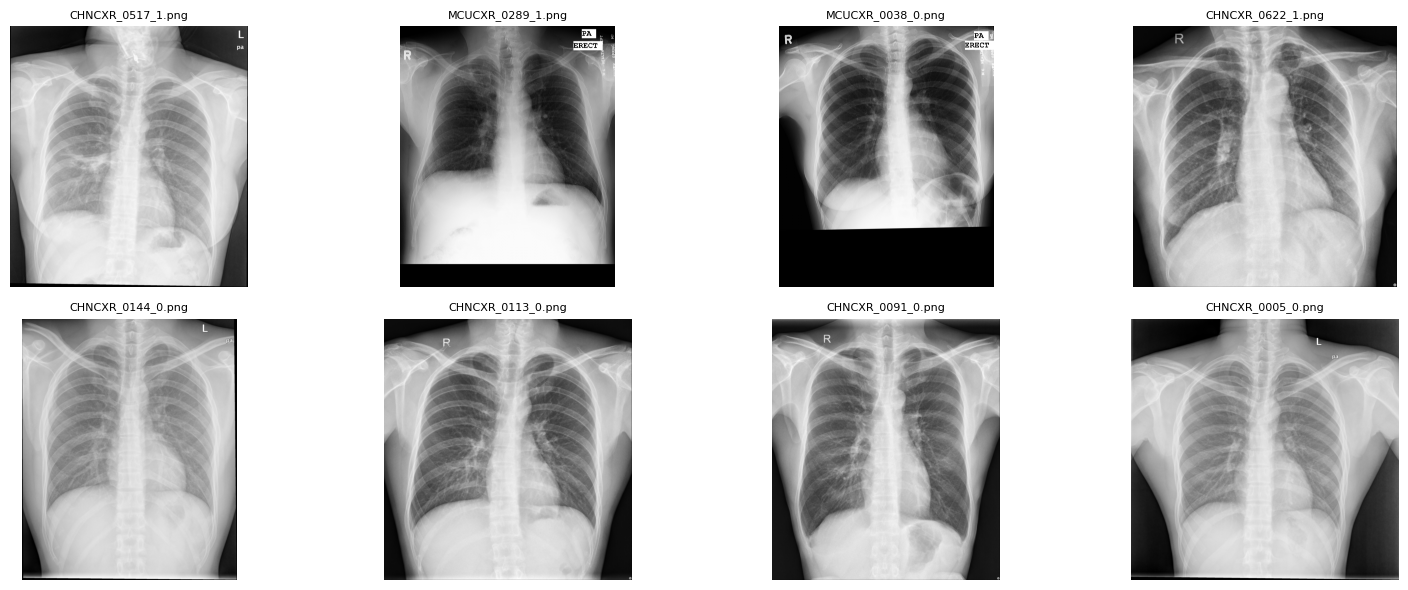

In [8]:
sample_paths = random.sample(image_paths, min(8, len(image_paths)))
plt.figure(figsize=(16, 6))
for i, p in enumerate(sample_paths, 1):
    img = Image.open(p).convert("L")
    plt.subplot(2, 4, i)
    plt.imshow(img, cmap="gray")
    plt.title(p.name, fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8. Metadata CSV discovery

This fixes the earlier blank metadata issue. Metadata files are not inside `images/images`; they are usually one folder above. Therefore we search from the shared `RAW_DIR`, not from the image folder.


In [9]:
metadata_csvs = sorted(list(RAW_DIR.rglob("*.csv")))
print("Metadata CSV files found:")
for p in metadata_csvs:
    print("-", p)

for p in metadata_csvs:
    try:
        df_tmp = pd.read_csv(p)
        print("\n", p.name, df_tmp.shape)
        print(df_tmp.head())
    except Exception as e:
        print("Could not read", p, e)

Metadata CSV files found:
- tbguard_project/data/cxr/raw/montgomery/montgomery_metadata.csv
- tbguard_project/data/cxr/raw/shenzhen/shenzhen_metadata.csv

 montgomery_metadata.csv (138, 4)
            study_id  age  gender findings
0  MCUCXR_0001_0.png   27  Female   normal
1  MCUCXR_0002_0.png   40  Female   normal
2  MCUCXR_0003_0.png   21  Female   normal
3  MCUCXR_0004_0.png   11  Female   normal
4  MCUCXR_0005_0.png   33    Male   normal

 shenzhen_metadata.csv (662, 4)
            study_id     sex  age findings
0  CHNCXR_0001_0.png    Male   45   normal
1  CHNCXR_0002_0.png    Male   63   normal
2  CHNCXR_0003_0.png  Female   48   normal
3  CHNCXR_0004_0.png    Male   58   normal
4  CHNCXR_0005_0.png    Male   28   normal


## 9. Build labels from filename convention and backup metadata

In [10]:
def infer_label_from_filename(path):
    name = Path(path).name.lower()

    # Common Montgomery/Shenzhen convention: final _0 / _1 before extension.
    if re.search(r"_0\.(png|jpg|jpeg)$", name):
        return 0
    if re.search(r"_1\.(png|jpg|jpeg)$", name):
        return 1

    # Backup rules if filenames are different.
    if "normal" in name or "non_tb" in name or "non-tb" in name:
        return 0
    if "tuberculosis" in name or re.search(r"(^|[_\-])tb([_\-]|\.)", name):
        return 1

    return None


def infer_dataset_name(path):
    s = str(path).lower()
    if "montgomery" in s or "mcucxr" in path.name.lower():
        return "montgomery"
    if "shenzhen" in s or "chncxr" in path.name.lower():
        return "shenzhen"
    return "unknown"

rows = []
unlabeled = []

for p in image_paths:
    label = infer_label_from_filename(p)
    if label is None:
        unlabeled.append(str(p))
        continue
    rows.append({
        "image_path": str(p),
        "filename": p.name,
        "label": int(label),
        "dataset": infer_dataset_name(p)
    })

cxr_df = pd.DataFrame(rows)
print("Labeled images:", len(cxr_df))
print("Unlabeled images:", len(unlabeled))
print(cxr_df.head())
print("\nLabel counts:")
print(cxr_df["label"].value_counts())
print("\nDataset counts:")
print(cxr_df["dataset"].value_counts())
print("\nDataset x label:")
print(pd.crosstab(cxr_df["dataset"], cxr_df["label"]))

if len(cxr_df) == 0:
    raise ValueError("No labels inferred. Check filename pattern or metadata files.")

if cxr_df["label"].nunique() < 2:
    raise ValueError("Only one class found. Need both normal and TB labels.")

CXR_DIR.mkdir(parents=True, exist_ok=True)
cxr_metadata_path = CXR_DIR / "cxr_metadata.csv"
cxr_df.to_csv(cxr_metadata_path, index=False)
print("Saved:", cxr_metadata_path)

Labeled images: 800
Unlabeled images: 0
                                          image_path           filename  \
0  tbguard_project/data/cxr/raw/montgomery/images...  MCUCXR_0001_0.png   
1  tbguard_project/data/cxr/raw/montgomery/images...  MCUCXR_0002_0.png   
2  tbguard_project/data/cxr/raw/montgomery/images...  MCUCXR_0003_0.png   
3  tbguard_project/data/cxr/raw/montgomery/images...  MCUCXR_0004_0.png   
4  tbguard_project/data/cxr/raw/montgomery/images...  MCUCXR_0005_0.png   

   label     dataset  
0      0  montgomery  
1      0  montgomery  
2      0  montgomery  
3      0  montgomery  
4      0  montgomery  

Label counts:
label
0    406
1    394
Name: count, dtype: int64

Dataset counts:
dataset
shenzhen      662
montgomery    138
Name: count, dtype: int64

Dataset x label:
label         0    1
dataset             
montgomery   80   58
shenzhen    326  336
Saved: tbguard_project/data/cxr/cxr_metadata.csv


## 10. Train/validation/test split

In [11]:
train_df, temp_df = train_test_split(
    cxr_df,
    test_size=0.30,
    stratify=cxr_df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df.to_csv(CXR_DIR / "train.csv", index=False)
val_df.to_csv(CXR_DIR / "val.csv", index=False)
test_df.to_csv(CXR_DIR / "test.csv", index=False)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val:", val_df.shape, val_df["label"].value_counts().to_dict())
print("Test:", test_df.shape, test_df["label"].value_counts().to_dict())

Train: (560, 4) {0: 284, 1: 276}
Val: (120, 4) {0: 61, 1: 59}
Test: (120, 4) {0: 61, 1: 59}


## 11. Dataset and transforms

In [12]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["image_path"]
        label = int(row["label"])

        img = Image.open(image_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

IMG_SIZE = 224

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=5),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

eval_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(CXRDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(CXRDataset(val_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(CXRDataset(test_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## 12. Build EfficientNet-B0 model

In [22]:
def build_cxr_model(pretrained=True):
    weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b0(weights=weights)

    # Freeze feature extractor for faster stable Colab training.
    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)
    return model

cxr_model = build_cxr_model(pretrained=True).to(DEVICE)

# Handle class imbalance in BCE loss.
num_pos = int(train_df["label"].sum())
num_neg = int((train_df["label"] == 0).sum())
pos_weight_value = num_neg / max(num_pos, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, cxr_model.parameters()), lr=1e-4, weight_decay=1e-4)

print("Positive samples:", num_pos)
print("Negative samples:", num_neg)
print("pos_weight:", pos_weight_value)

Positive samples: 276
Negative samples: 284
pos_weight: 1.0289855072463767


## 13. Training/evaluation helpers

In [23]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    for images, labels in tqdm(loader, leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()

        total_loss += loss.item() * images.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(labs.tolist())

    avg_loss = total_loss / len(loader.dataset)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    y_true = np.array(all_labels).astype(int)

    metrics = {
        "loss": float(avg_loss),
        "accuracy": float(accuracy_score(y_true, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, preds)),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, all_probs))
    except Exception:
        metrics["roc_auc"] = float("nan")

    try:
        metrics["pr_auc"] = float(average_precision_score(y_true, all_probs))
    except Exception:
        metrics["pr_auc"] = float("nan")

    return metrics


def collect_predictions(model, loader):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.numpy().tolist())

    return np.array(all_labels).astype(int), np.array(all_probs)

## 14. Train and save best model

In [24]:
EPOCHS = 10  # Increase to 8-15 if you have time/Colab Pro+
best_val_auc = -1
best_path = MODEL_DIR / "cxr_efficientnet_b0_tb.pt"
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")

    train_metrics = run_epoch(cxr_model, train_loader, optimizer)
    val_metrics = run_epoch(cxr_model, val_loader, optimizer=None)

    row = {"epoch": epoch}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    history.append(row)
    print(json.dumps(row, indent=2))

    val_auc = val_metrics.get("roc_auc", float("nan"))
    if np.isnan(val_auc):
        val_auc = val_metrics.get("balanced_accuracy", -1)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            "model_state_dict": cxr_model.state_dict(),
            "img_size": IMG_SIZE,
            "model_name": "efficientnet_b0",
            "label_mapping": {"normal": 0, "tb": 1},
            "pos_weight": float(pos_weight_value),
            "train_rows": int(len(train_df)),
            "val_rows": int(len(val_df)),
            "test_rows": int(len(test_df)),
            "dataset_sources": sorted(cxr_df["dataset"].unique().tolist())
        }, best_path)
        print("Saved best model:", best_path)

history_df = pd.DataFrame(history)
history_path = MODEL_DIR / "cxr_training_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved history:", history_path)

Epoch 1/10


{
  "epoch": 1,
  "train_loss": 0.7193356684276035,
  "train_accuracy": 0.43392857142857144,
  "train_balanced_accuracy": 0.43409369259032454,
  "train_f1": 0.4369449378330373,
  "train_recall": 0.44565217391304346,
  "train_precision": 0.42857142857142855,
  "train_roc_auc": 0.4129924474382527,
  "train_pr_auc": 0.43643511590973105,
  "val_loss": 0.7005814711252848,
  "val_accuracy": 0.5416666666666666,
  "val_balanced_accuracy": 0.5439010836343429,
  "val_f1": 0.5925925925925926,
  "val_recall": 0.6779661016949152,
  "val_precision": 0.5263157894736842,
  "val_roc_auc": 0.5518199499861073,
  "val_pr_auc": 0.5240817056802047
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 2/10


{
  "epoch": 2,
  "train_loss": 0.6938677430152893,
  "train_accuracy": 0.5678571428571428,
  "train_balanced_accuracy": 0.5686364564196775,
  "train_f1": 0.5870307167235495,
  "train_recall": 0.6231884057971014,
  "train_precision": 0.5548387096774193,
  "train_roc_auc": 0.5905159216166564,
  "train_pr_auc": 0.5550039848887196,
  "val_loss": 0.6789185166358948,
  "val_accuracy": 0.6416666666666667,
  "val_balanced_accuracy": 0.6422617393720478,
  "val_f1": 0.6504065040650406,
  "val_recall": 0.6779661016949152,
  "val_precision": 0.625,
  "val_roc_auc": 0.6765768268963601,
  "val_pr_auc": 0.6176994924104429
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 3/10


{
  "epoch": 3,
  "train_loss": 0.687200265271323,
  "train_accuracy": 0.5982142857142857,
  "train_balanced_accuracy": 0.5994845886915696,
  "train_f1": 0.628099173553719,
  "train_recall": 0.6884057971014492,
  "train_precision": 0.5775075987841946,
  "train_roc_auc": 0.6327439273321086,
  "train_pr_auc": 0.6101271351160023,
  "val_loss": 0.662632950146993,
  "val_accuracy": 0.6583333333333333,
  "val_balanced_accuracy": 0.6594887468741317,
  "val_f1": 0.6771653543307087,
  "val_recall": 0.7288135593220338,
  "val_precision": 0.6323529411764706,
  "val_roc_auc": 0.7513198110586272,
  "val_pr_auc": 0.7551625445777588
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 4/10


{
  "epoch": 4,
  "train_loss": 0.6720793110983713,
  "train_accuracy": 0.6642857142857143,
  "train_balanced_accuracy": 0.6648805878750765,
  "train_f1": 0.6747404844290658,
  "train_recall": 0.7065217391304348,
  "train_precision": 0.6456953642384106,
  "train_roc_auc": 0.7011507450500103,
  "train_pr_auc": 0.6827312824323433,
  "val_loss": 0.6475601156552633,
  "val_accuracy": 0.7083333333333334,
  "val_balanced_accuracy": 0.7083912197832731,
  "val_f1": 0.7058823529411765,
  "val_recall": 0.711864406779661,
  "val_precision": 0.7,
  "val_roc_auc": 0.7941094748541262,
  "val_pr_auc": 0.80026122678191
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 5/10


...

{
  "epoch": 6,
  "train_loss": 0.6545022504670279,
  "train_accuracy": 0.6964285714285714,
  "train_balanced_accuracy": 0.696570728720147,
  "train_f1": 0.6964285714285714,
  "train_recall": 0.7065217391304348,
  "train_precision": 0.6866197183098591,
  "train_roc_auc": 0.7477163706878954,
  "train_pr_auc": 0.7274776434963552,
  "val_loss": 0.6188732385635376,
  "val_accuracy": 0.7583333333333333,
  "val_balanced_accuracy": 0.7575715476521256,
  "val_f1": 0.7433628318584071,
  "val_recall": 0.711864406779661,
  "val_precision": 0.7777777777777778,
  "val_roc_auc": 0.8391219783273131,
  "val_pr_auc": 0.8529681860735266
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 7/10


{
  "epoch": 7,
  "train_loss": 0.6362815311976842,
  "train_accuracy": 0.725,
  "train_balanced_accuracy": 0.7255052051439069,
  "train_f1": 0.7317073170731707,
  "train_recall": 0.7608695652173914,
  "train_precision": 0.7046979865771812,
  "train_roc_auc": 0.7895361298224128,
  "train_pr_auc": 0.7860298981347086,
  "val_loss": 0.6086086988449096,
  "val_accuracy": 0.7583333333333333,
  "val_balanced_accuracy": 0.7581272575715476,
  "val_f1": 0.7521367521367521,
  "val_recall": 0.7457627118644068,
  "val_precision": 0.7586206896551724,
  "val_roc_auc": 0.8519033064740207,
  "val_pr_auc": 0.8650106808139699
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 8/10


{
  "epoch": 8,
  "train_loss": 0.638307385785239,
  "train_accuracy": 0.7160714285714286,
  "train_balanced_accuracy": 0.7164472341294141,
  "train_f1": 0.7205623901581723,
  "train_recall": 0.7427536231884058,
  "train_precision": 0.6996587030716723,
  "train_roc_auc": 0.7732062665850173,
  "train_pr_auc": 0.7336058218898528,
  "val_loss": 0.598069945971171,
  "val_accuracy": 0.7833333333333333,
  "val_balanced_accuracy": 0.7821617115865518,
  "val_f1": 0.7636363636363637,
  "val_recall": 0.711864406779661,
  "val_precision": 0.8235294117647058,
  "val_roc_auc": 0.8660739094192831,
  "val_pr_auc": 0.8805717959201815
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 9/10


{
  "epoch": 9,
  "train_loss": 0.6312468273299081,
  "train_accuracy": 0.7071428571428572,
  "train_balanced_accuracy": 0.7074913247601551,
  "train_f1": 0.7112676056338029,
  "train_recall": 0.7318840579710145,
  "train_precision": 0.6917808219178082,
  "train_roc_auc": 0.776319146764646,
  "train_pr_auc": 0.77090676780302,
  "val_loss": 0.5875752290089925,
  "val_accuracy": 0.8,
  "val_balanced_accuracy": 0.7991108641289246,
  "val_f1": 0.7857142857142857,
  "val_recall": 0.7457627118644068,
  "val_precision": 0.8301886792452831,
  "val_roc_auc": 0.8705195887746597,
  "val_pr_auc": 0.8853068375280837
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Epoch 10/10


{
  "epoch": 10,
  "train_loss": 0.6158102904047285,
  "train_accuracy": 0.7196428571428571,
  "train_balanced_accuracy": 0.7200193917125943,
  "train_f1": 0.7240773286467487,
  "train_recall": 0.7463768115942029,
  "train_precision": 0.7030716723549488,
  "train_roc_auc": 0.8004184527454583,
  "train_pr_auc": 0.7996013925655863,
  "val_loss": 0.5760737737019856,
  "val_accuracy": 0.8,
  "val_balanced_accuracy": 0.7993887190886357,
  "val_f1": 0.7894736842105263,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8181818181818182,
  "val_roc_auc": 0.8796888024451236,
  "val_pr_auc": 0.8952722758277626
}
Saved best model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Saved history: tbguard_project/artifacts/models/cxr_training_history.csv


In [25]:
# 14B. Light fine-tuning for better CXR separation
# Run this after the initial classifier-head training in Section 14.
# It unfreezes only the last EfficientNet blocks, so it is still lightweight.

FINE_TUNE_EPOCHS = 5
FINE_TUNE_LR = 1e-5

# Start from the current/best saved model after Section 14
checkpoint = torch.load(best_path, map_location=DEVICE)
cxr_model.load_state_dict(checkpoint["model_state_dict"])
cxr_model = cxr_model.to(DEVICE)

# Freeze everything first
for param in cxr_model.features.parameters():
    param.requires_grad = False

# Unfreeze only the last 2 EfficientNet feature blocks
for block in cxr_model.features[-2:]:
    for param in block.parameters():
        param.requires_grad = True

# Keep classifier trainable
for param in cxr_model.classifier.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cxr_model.parameters()),
    lr=FINE_TUNE_LR,
    weight_decay=1e-5
)

print("Fine-tuning last EfficientNet blocks.")
print("Trainable parameters:", sum(p.numel() for p in cxr_model.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in cxr_model.parameters()))

fine_tune_history = []

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    print(f"Fine-tune epoch {epoch}/{FINE_TUNE_EPOCHS}")

    train_metrics = run_epoch(cxr_model, train_loader, optimizer)
    val_metrics = run_epoch(cxr_model, val_loader, optimizer=None)

    row = {"fine_tune_epoch": epoch}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    fine_tune_history.append(row)

    print(json.dumps(row, indent=2))

    val_auc = val_metrics.get("roc_auc", float("nan"))
    if np.isnan(val_auc):
        val_auc = val_metrics.get("balanced_accuracy", -1)

    # Save if fine-tuning improves validation score
    if val_auc > best_val_auc:
        best_val_auc = val_auc

        torch.save({
            "model_state_dict": cxr_model.state_dict(),
            "img_size": IMG_SIZE,
            "model_name": "efficientnet_b0",
            "label_mapping": {"normal": 0, "tb": 1},
            "pos_weight": float(pos_weight_value),
            "train_rows": int(len(train_df)),
            "val_rows": int(len(val_df)),
            "test_rows": int(len(test_df)),
            "dataset_sources": sorted(cxr_df["dataset"].unique().tolist()),
            "fine_tuned": True,
            "fine_tune_epochs": FINE_TUNE_EPOCHS,
            "fine_tune_lr": FINE_TUNE_LR
        }, best_path)

        print("Saved improved fine-tuned model:", best_path)

fine_tune_history_df = pd.DataFrame(fine_tune_history)
fine_tune_history_path = MODEL_DIR / "cxr_fine_tune_history.csv"
fine_tune_history_df.to_csv(fine_tune_history_path, index=False)

print("Saved fine-tune history:", fine_tune_history_path)
print("Best validation score after fine-tuning:", best_val_auc)

Fine-tuning last EfficientNet blocks.
Trainable parameters: 1130673
Total parameters: 4008829
Fine-tune epoch 1/5


{
  "fine_tune_epoch": 1,
  "train_loss": 0.598071585382734,
  "train_accuracy": 0.7535714285714286,
  "train_balanced_accuracy": 0.7540824658093488,
  "train_f1": 0.759581881533101,
  "train_recall": 0.7898550724637681,
  "train_precision": 0.7315436241610739,
  "train_roc_auc": 0.8311517656664624,
  "train_pr_auc": 0.844319469319027,
  "val_loss": 0.5623448292414347,
  "val_accuracy": 0.8083333333333333,
  "val_balanced_accuracy": 0.807585440400111,
  "val_f1": 0.7964601769911505,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8333333333333334,
  "val_roc_auc": 0.8885801611558767,
  "val_pr_auc": 0.904374326662895
}
Saved improved fine-tuned model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Fine-tune epoch 2/5


{
  "fine_tune_epoch": 2,
  "train_loss": 0.604862288066319,
  "train_accuracy": 0.7196428571428571,
  "train_balanced_accuracy": 0.7200704225352113,
  "train_f1": 0.7250437828371279,
  "train_recall": 0.75,
  "train_precision": 0.7016949152542373,
  "train_roc_auc": 0.8003929373341498,
  "train_pr_auc": 0.8153166892370216,
  "val_loss": 0.5511444568634033,
  "val_accuracy": 0.8083333333333333,
  "val_balanced_accuracy": 0.807585440400111,
  "val_f1": 0.7964601769911505,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8333333333333334,
  "val_roc_auc": 0.8949708252292302,
  "val_pr_auc": 0.9106678903717423
}
Saved improved fine-tuned model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Fine-tune epoch 3/5


{
  "fine_tune_epoch": 3,
  "train_loss": 0.5950364674840655,
  "train_accuracy": 0.7464285714285714,
  "train_balanced_accuracy": 0.7467340273525209,
  "train_f1": 0.7491166077738516,
  "train_recall": 0.7681159420289855,
  "train_precision": 0.7310344827586207,
  "train_roc_auc": 0.8152684221269647,
  "train_pr_auc": 0.8281480249454979,
  "val_loss": 0.5391456246376037,
  "val_accuracy": 0.8083333333333333,
  "val_balanced_accuracy": 0.807585440400111,
  "val_f1": 0.7964601769911505,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8333333333333334,
  "val_roc_auc": 0.8971936649069187,
  "val_pr_auc": 0.9122408215140977
}
Saved improved fine-tuned model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Fine-tune epoch 4/5


{
  "fine_tune_epoch": 4,
  "train_loss": 0.5857181915215084,
  "train_accuracy": 0.7357142857142858,
  "train_balanced_accuracy": 0.7362727087160645,
  "train_f1": 0.7430555555555556,
  "train_recall": 0.7753623188405797,
  "train_precision": 0.7133333333333334,
  "train_roc_auc": 0.8201163502755666,
  "train_pr_auc": 0.829026683719396,
  "val_loss": 0.5320526440938314,
  "val_accuracy": 0.8083333333333333,
  "val_balanced_accuracy": 0.807585440400111,
  "val_f1": 0.7964601769911505,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8333333333333334,
  "val_roc_auc": 0.9016393442622952,
  "val_pr_auc": 0.9159243065924771
}
Saved improved fine-tuned model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Fine-tune epoch 5/5


{
  "fine_tune_epoch": 5,
  "train_loss": 0.57589396578925,
  "train_accuracy": 0.7642857142857142,
  "train_balanced_accuracy": 0.7645437844458053,
  "train_f1": 0.7659574468085106,
  "train_recall": 0.782608695652174,
  "train_precision": 0.75,
  "train_roc_auc": 0.8324913247601551,
  "train_pr_auc": 0.8479079562146827,
  "val_loss": 0.5179771383603414,
  "val_accuracy": 0.8083333333333333,
  "val_balanced_accuracy": 0.807585440400111,
  "val_f1": 0.7964601769911505,
  "val_recall": 0.7627118644067796,
  "val_precision": 0.8333333333333334,
  "val_roc_auc": 0.9035843289802723,
  "val_pr_auc": 0.9182661890417936
}
Saved improved fine-tuned model: tbguard_project/artifacts/models/cxr_efficientnet_b0_tb.pt
Saved fine-tune history: tbguard_project/artifacts/models/cxr_fine_tune_history.csv
Best validation score after fine-tuning: 0.9035843289802723


## 15. Load best model and tune threshold on validation set

In [26]:
def build_cxr_model_for_load():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)
    return model

checkpoint = torch.load(best_path, map_location=DEVICE)
best_model = build_cxr_model_for_load().to(DEVICE)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

val_y, val_prob = collect_predictions(best_model, val_loader)

threshold_rows = []
best_threshold = 0.5
best_bal_acc = -1

for th in np.linspace(0.05, 0.95, 181):
    pred = (val_prob >= th).astype(int)
    row = {
        "threshold": float(th),
        "accuracy": float(accuracy_score(val_y, pred)),
        "balanced_accuracy": float(balanced_accuracy_score(val_y, pred)),
        "precision": float(precision_score(val_y, pred, zero_division=0)),
        "recall": float(recall_score(val_y, pred, zero_division=0)),
        "f1": float(f1_score(val_y, pred, zero_division=0))
    }
    threshold_rows.append(row)
    if row["balanced_accuracy"] > best_bal_acc:
        best_bal_acc = row["balanced_accuracy"]
        best_threshold = float(th)

threshold_df = pd.DataFrame(threshold_rows)
threshold_path = MODEL_DIR / "cxr_threshold_search.csv"
threshold_df.to_csv(threshold_path, index=False)

print("Best threshold:", best_threshold)
print("Best validation balanced accuracy:", best_bal_acc)
print("Saved threshold search:", threshold_path)

Best threshold: 0.4649999999999999
Best validation balanced accuracy: 0.8332870241733815
Saved threshold search: tbguard_project/artifacts/models/cxr_threshold_search.csv


## 16. Final test evaluation

In [27]:
test_y, test_prob = collect_predictions(best_model, test_loader)
test_pred = (test_prob >= best_threshold).astype(int)

final_metrics = {
    "threshold": float(best_threshold),
    "accuracy": float(accuracy_score(test_y, test_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(test_y, test_pred)),
    "precision": float(precision_score(test_y, test_pred, zero_division=0)),
    "recall_sensitivity": float(recall_score(test_y, test_pred, zero_division=0)),
    "f1": float(f1_score(test_y, test_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(test_y, test_prob)),
    "pr_auc": float(average_precision_score(test_y, test_prob)),
    "confusion_matrix": confusion_matrix(test_y, test_pred).tolist()
}

print(json.dumps(final_metrics, indent=2))
print(classification_report(test_y, test_pred, target_names=["Normal / non-TB", "TB"], zero_division=0))

{
  "threshold": 0.4649999999999999,
  "accuracy": 0.8,
  "balanced_accuracy": 0.8002222839677688,
  "precision": 0.7868852459016393,
  "recall_sensitivity": 0.8135593220338984,
  "f1": 0.8,
  "roc_auc": 0.8455126424006669,
  "pr_auc": 0.8697525511064075,
  "confusion_matrix": [
    [
      48,
      13
    ],
    [
      11,
      48
    ]
  ]
}
                 precision    recall  f1-score   support

Normal / non-TB       0.81      0.79      0.80        61
             TB       0.79      0.81      0.80        59

       accuracy                           0.80       120
      macro avg       0.80      0.80      0.80       120
   weighted avg       0.80      0.80      0.80       120



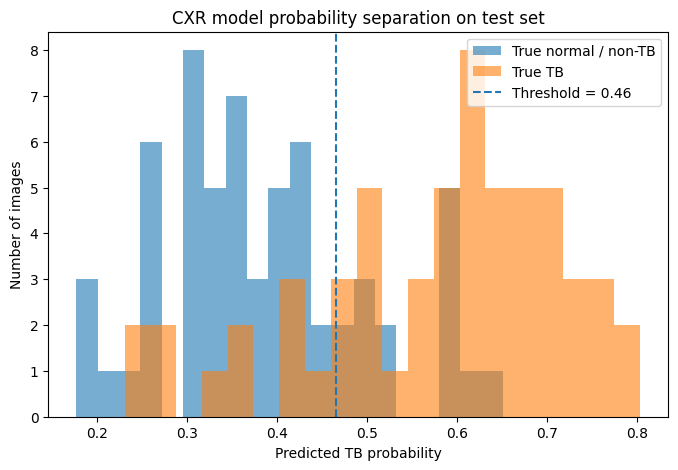

Saved: tbguard_project/artifacts/models/cxr_test_probability_scores.csv

Mean probability by true label:
label
0    0.386281
1    0.574514
Name: tb_probability, dtype: float64

Median probability by true label:
label
0    0.364670
1    0.611045
Name: tb_probability, dtype: float64


In [28]:
# 16B. Visualize CXR probability separation on test set

test_result_df = test_df.copy()
test_result_df["tb_probability"] = test_prob
test_result_df["predicted_label"] = test_pred

plt.figure(figsize=(8, 5))
plt.hist(
    test_result_df[test_result_df["label"] == 0]["tb_probability"],
    bins=20,
    alpha=0.6,
    label="True normal / non-TB"
)
plt.hist(
    test_result_df[test_result_df["label"] == 1]["tb_probability"],
    bins=20,
    alpha=0.6,
    label="True TB"
)
plt.axvline(best_threshold, linestyle="--", label=f"Threshold = {best_threshold:.2f}")
plt.xlabel("Predicted TB probability")
plt.ylabel("Number of images")
plt.title("CXR model probability separation on test set")
plt.legend()
plt.show()

separation_path = MODEL_DIR / "cxr_test_probability_scores.csv"
test_result_df.to_csv(separation_path, index=False)

print("Saved:", separation_path)
print("\nMean probability by true label:")
print(test_result_df.groupby("label")["tb_probability"].mean())
print("\nMedian probability by true label:")
print(test_result_df.groupby("label")["tb_probability"].median())

## 17. Save metadata and inference helper

In [29]:
metadata = {
    "model_file": str(best_path),
    "model_name": "EfficientNet-B0 CXR TB classifier",
    "threshold": float(best_threshold),
    "img_size": IMG_SIZE,
    "label_mapping": {"normal": 0, "tb": 1},
    "datasets": sorted(cxr_df["dataset"].unique().tolist()),
    "num_images": int(len(cxr_df)),
    "label_counts": {str(k): int(v) for k, v in cxr_df["label"].value_counts().to_dict().items()},
    "dataset_label_counts": pd.crosstab(cxr_df["dataset"], cxr_df["label"]).to_dict(),
    "final_test_metrics": final_metrics,
    "note": "Artifact is intended for TBGuard Notebook 4 LangGraph/Gradio workflow."
}

metadata_path = MODEL_DIR / "cxr_model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved metadata:", metadata_path)


def predict_cxr_image(image_path, model=None, threshold=None):
    if model is None:
        model = best_model
    if threshold is None:
        threshold = best_threshold

    img = Image.open(image_path).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit = model(x).squeeze()
        prob = torch.sigmoid(logit).item()

    pred = int(prob >= threshold)
    if prob >= threshold + 0.20:
        confidence = "high"
    elif prob >= threshold:
        confidence = "medium"
    else:
        confidence = "low"

    return {
        "model_name": "EfficientNet-B0 CXR TB classifier",
        "tb_probability": round(float(prob), 4),
        "threshold": round(float(threshold), 4),
        "predicted_class_id": pred,
        "predicted_class": "TB" if pred == 1 else "Normal / Low TB",
        "confidence": confidence,
        "image_path": str(image_path)
    }

sample_img = test_df.iloc[0]["image_path"]
print(json.dumps(predict_cxr_image(sample_img), indent=2))

Saved metadata: tbguard_project/artifacts/models/cxr_model_metadata.json
{
  "model_name": "EfficientNet-B0 CXR TB classifier",
  "tb_probability": 0.4946,
  "threshold": 0.465,
  "predicted_class_id": 1,
  "predicted_class": "TB",
  "confidence": "medium",
  "image_path": "tbguard_project/data/cxr/raw/montgomery/images/images/MCUCXR_0223_1.png"
}


## 18. Export demo images for Notebook 4

Notebook 4 needs a few real X-ray files for the 3-patient demo. This exports representative normal/TB images.


In [30]:
# Section 18. Export CLEAR demo images for Notebook 4
# This version does not simply pick the first normal/TB images.
# It scores the test set and chooses:
#   - the known label-0 image with the lowest TB probability
#   - the known label-1 image with the highest TB probability

if DEMO_IMG_DIR.exists():
    shutil.rmtree(DEMO_IMG_DIR)
DEMO_IMG_DIR.mkdir(parents=True, exist_ok=True)

demo_score_rows = []

for _, row in test_df.iterrows():
    image_path = row["image_path"]
    true_label = int(row["label"])

    try:
        pred = predict_cxr_image(image_path, model=best_model, threshold=best_threshold)
        demo_score_rows.append({
            "image_path": image_path,
            "filename": Path(image_path).name,
            "true_label": true_label,
            "tb_probability": float(pred["tb_probability"]),
            "predicted_class": pred["predicted_class"],
            "confidence": pred["confidence"]
        })
    except Exception as e:
        print("Skipped:", image_path, e)

demo_scores_df = pd.DataFrame(demo_score_rows)

if demo_scores_df.empty:
    raise RuntimeError("No test images could be scored. Check test_df image paths and model.")

print("Scored test images:", demo_scores_df.shape)
print("\nTB probability summary by true label:")
display(demo_scores_df.groupby("true_label")["tb_probability"].describe())

if 0 not in demo_scores_df["true_label"].unique():
    raise ValueError("No known normal / label 0 image found in test set.")

if 1 not in demo_scores_df["true_label"].unique():
    raise ValueError("No known TB / label 1 image found in test set.")

# Clearest label 0: lowest TB probability
clear_normal = (
    demo_scores_df[demo_scores_df["true_label"] == 0]
    .sort_values("tb_probability", ascending=True)
    .iloc[0]
)

# Clearest label 1: highest TB probability
clear_tb = (
    demo_scores_df[demo_scores_df["true_label"] == 1]
    .sort_values("tb_probability", ascending=False)
    .iloc[0]
)

print("\nClearest known NORMAL / label 0:")
print(clear_normal)

print("\nClearest known TB / label 1:")
print(clear_tb)

# Save clean two-image demo pair
normal_src = clear_normal["image_path"]
tb_src = clear_tb["image_path"]

normal_dest = DEMO_IMG_DIR / "clear_normal_0.png"
tb_dest = DEMO_IMG_DIR / "clear_tb_1.png"

shutil.copy2(normal_src, normal_dest)
shutil.copy2(tb_src, tb_dest)

# Also keep the old three-patient names for Notebook 4 compatibility
patient1_dest = DEMO_IMG_DIR / "patient1_low_suspicion_normal.png"
patient2_dest = DEMO_IMG_DIR / "patient2_likely_tb.png"
patient3_dest = DEMO_IMG_DIR / "patient3_mdr_context_tb.png"

shutil.copy2(normal_src, patient1_dest)
shutil.copy2(tb_src, patient2_dest)
shutil.copy2(tb_src, patient3_dest)

print("\nSaved clear normal:", normal_dest)
print("Saved clear TB:", tb_dest)
print("Saved patient 1 demo:", patient1_dest)
print("Saved patient 2 demo:", patient2_dest)
print("Saved patient 3 demo:", patient3_dest)

print("\nPrediction on clear normal:")
print(json.dumps(predict_cxr_image(str(normal_dest), model=best_model, threshold=best_threshold), indent=2))

print("\nPrediction on clear TB:")
print(json.dumps(predict_cxr_image(str(tb_dest), model=best_model, threshold=best_threshold), indent=2))

# Save the scored image table for traceability
demo_scores_path = MODEL_DIR / "cxr_demo_image_scores.csv"
demo_scores_df.to_csv(demo_scores_path, index=False)
print("\nSaved demo image score table:", demo_scores_path)

# Zip demo images
demo_zip = EXPORT_DIR / "demo_cxr_images.zip"
if demo_zip.exists():
    demo_zip.unlink()

shutil.make_archive(str(demo_zip).replace(".zip", ""), "zip", DEMO_IMG_DIR)
print("Saved demo images ZIP:", demo_zip)

Scored test images: (120, 6)

TB probability summary by true label:


,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,61.0,0.386618,0.113422,0.1748,0.31250,0.3644,0.4589,0.6497
1,59.0,0.575039,0.140915,0.2303,0.49335,0.6125,0.6779,0.8033



Clearest known NORMAL / label 0:
image_path         tbguard_project/data/cxr/raw/shenzhen/images/i...
filename                                           CHNCXR_0049_0.png
true_label                                                         0
tb_probability                                                0.1748
predicted_class                                      Normal / Low TB
confidence                                                       low
Name: 99, dtype: object

Clearest known TB / label 1:
image_path         tbguard_project/data/cxr/raw/shenzhen/images/i...
filename                                           CHNCXR_0537_1.png
true_label                                                         1
tb_probability                                                0.8033
predicted_class                                                   TB
confidence                                                      high
Name: 17, dtype: object

Saved clear normal: tbguard_project/demo_images/clear_norma

## 19. Export artifacts for Notebook 4

In [31]:
artifact_export_dir = EXPORT_DIR / "cxr_model_artifacts"
if artifact_export_dir.exists():
    shutil.rmtree(artifact_export_dir)
artifact_export_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    MODEL_DIR / "cxr_fine_tune_history.csv",
    MODEL_DIR / "cxr_test_probability_scores.csv",
    MODEL_DIR / "cxr_demo_image_scores.csv",
    MODEL_DIR / "cxr_efficientnet_b0_tb.pt",
    MODEL_DIR / "cxr_model_metadata.json",
    MODEL_DIR / "cxr_training_history.csv",
    MODEL_DIR / "cxr_threshold_search.csv",
    CXR_DIR / "cxr_metadata.csv",
    CXR_DIR / "train.csv",
    CXR_DIR / "val.csv",
    CXR_DIR / "test.csv",
]

for f in files_to_copy:
    if f.exists():
        shutil.copy(f, artifact_export_dir / f.name)
        print("Copied:", f.name)
    else:
        print("Missing, skipped:", f)

# Add demo images folder inside artifact export.
shutil.copytree(DEMO_IMG_DIR, artifact_export_dir / "demo_images", dirs_exist_ok=True)

zip_base = EXPORT_DIR / "cxr_model_artifacts"
zip_path = shutil.make_archive(str(zip_base), "zip", artifact_export_dir)
print("Saved artifact ZIP:", zip_path)

try:
    from google.colab import files
    files.download(str(MODEL_DIR / "cxr_efficientnet_b0_tb.pt"))
    files.download(str(MODEL_DIR / "cxr_model_metadata.json"))
    files.download(str(demo_zip))
    files.download(str(zip_path))
except Exception as e:
    print("Download skipped outside Colab:", e)

Copied: cxr_fine_tune_history.csv
Copied: cxr_test_probability_scores.csv
Copied: cxr_demo_image_scores.csv
Copied: cxr_efficientnet_b0_tb.pt
Copied: cxr_model_metadata.json
Copied: cxr_training_history.csv
Copied: cxr_threshold_search.csv
Copied: cxr_metadata.csv
Copied: train.csv
Copied: val.csv
Copied: test.csv
Saved artifact ZIP: /content/tbguard_project/exports/cxr_model_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. What to upload into Notebook 4

Upload these to Notebook 4:

```text
cxr_efficientnet_b0_tb.pt
clinical_tb_model.joblib
genomic_resistance_model.joblib
who_mutation_catalogue_rag_text.txt   # recommended
patient1_low_suspicion_normal.png
patient2_likely_tb.png
patient3_mdr_context_tb.png
```

The three images are inside `demo_cxr_images.zip`. Notebook 4 can also accept your own three images as long as they are real CXR files.
